# Computer Exercise 14.8 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.8 Adaptive Learning-Rate Methods — 좌표별 적응 학습률 (AdaGrad)
> **풀이 일자**: 2026-07-08 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **1.** Consider online least-squares regression on a stream whose feature columns have
> **very different scales** (an ill-conditioned design). Implement **AdaGrad**, which keeps a
> per-coordinate running sum of squared gradients $G_{t,j}=\sum_{s\le t} g_{s,j}^2$ and rescales
> each coordinate's step by $1/\sqrt{G_{t,j}}$. Compare its convergence against plain SGD with a
> single scalar step-size schedule $\eta_t=\eta_0/\sqrt t$. Explain why a single global learning
> rate cannot serve all coordinates at once, and identify AdaGrad's long-run weakness.

### 한국어 풀이용 정리
피처 스케일이 서로 크게 다른(**ill-conditioned**) 정상 스트림에서 온라인 최소제곱을 푼다.
**AdaGrad** 는 좌표마다 그래디언트 제곱합 $G_{t,j}$ 을 누적해 스텝을 $\eta_0/\sqrt{G_{t,j}}$ 로
**좌표별 자동 조정**한다. 하나의 스칼라 학습률을 쓰는 SGD(스케줄 $\eta_0/\sqrt t$)와 비교하고,
왜 단일 학습률이 모든 좌표를 동시에 만족시킬 수 없는지, 그리고 AdaGrad 의 장기적 약점이
무엇인지 설명한다.

## 2. 수학적 배경

### 2.1 스케일 불일치가 만드는 조건수
설계행렬의 열이 스케일 $s_j$ 로 다르면 헤시안 $H=\mathbb E[\phi\phi^\top]$ 의 고윳값도
$\propto s_j^2$ 로 벌어져 **조건수** $\kappa(H)=\lambda_\max/\lambda_\min$ 가 커진다.
경사하강의 수렴률은 $\big(\tfrac{\kappa-1}{\kappa+1}\big)$ 로 지배되므로 큰 $\kappa$ 는 느린 수렴을 뜻한다.

### 2.2 단일 학습률의 딜레마
SGD 갱신 $\hat\beta_{t}=\hat\beta_{t-1}+\eta_t\,e_t\,\phi_t$ 에서 스텝은 모든 좌표에 **같은 $\eta_t$**.
안정성은 가장 큰 곡률 좌표가 요구하는 $\eta<2/\lambda_\max$ 로 제한되는데, 그러면 가장 작은 곡률
좌표는 $\eta\lambda_\min\ll1$ 이라 **거의 움직이지 못한다**. 즉
$$\boxed{\;\eta\ \text{하나로는 큰 곡률(안정성)과 작은 곡률(속도)을 동시에 만족할 수 없다.}\;}$$

### 2.3 AdaGrad
좌표별 누적 $G_{t,j}=\sum_{s\le t}g_{s,j}^2$ 을 두고
$$\hat\beta_{t,j}=\hat\beta_{t-1,j}-\frac{\eta_0}{\sqrt{G_{t,j}}+\varepsilon}\,g_{t,j}.$$
큰 그래디언트를 받은 좌표는 자동으로 스텝이 줄고, 작은 좌표는 큰 스텝을 유지 →
**전처리(preconditioning)** 효과로 스케일 불일치를 상쇄한다.
약점: $G_{t,j}$ 가 **단조 증가**하므로 유효 스텝 $\eta_0/\sqrt{G_{t,j}}\to0$,
장기적으로 학습이 **멈춘다**(정상 문제에선 무해하나 비정상 스트림에선 치명적 → Problem 2).

## 3. 풀이 흐름

1. **ill-conditioned 정상 스트림 생성**: $\phi_t=[1,\,10x_t,\,0.1x_t^2]^\top$ — 열 스케일 $1:10:0.1$,
   참계수 $\beta^\star=(2,-1,0.5)$, 잡음 $\varepsilon_t\sim\mathcal N(0,0.3^2)$.
2. **SGD 함수**: 스케줄 $\eta_t=\eta_0/\sqrt t$ 로 계수/오차 궤적 반환.
3. **AdaGrad 함수**: 좌표별 $G$ 누적, 유효 스텝 궤적도 함께 기록.
4. **스윕**: SGD 는 $\eta_0\in\{0.01,0.02,0.05\}$, AdaGrad 는 $\eta_0\in\{0.05,0.1,0.2,0.5\}$.
5. **tail 오차**(마지막 2000스텝 평균 $\lVert\hat\beta-\beta^\star\rVert$)로 정량 비교, 표 출력.
6. **시각화**: (좌) 오차 궤적 로그-로그, (우) AdaGrad 좌표별 유효 스텝 감쇠.
7. **해석**: 전처리 효과와 $G$ 단조증가로 인한 장기 정체.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260708)
T = 20000
sigma = 0.30
beta_star = np.array([2.0, -1.0, 0.5])
p = beta_star.size

# ill-conditioned design: column scales 1 : 10 : 0.1
x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), 10.0 * x, 0.1 * x**2], axis=1)
y = Phi @ beta_star + rng.normal(0, sigma, T)

# 조건수 확인 (경험적 2차 모멘트)
H = (Phi.T @ Phi) / T
print(f"empirical Hessian condition number kappa = {np.linalg.cond(H):.1f}")


def run_sgd(eta0, alpha=0.5):
    b = np.zeros(p); err = np.zeros(T)
    for t in range(T):
        e = y[t] - Phi[t] @ b
        b += eta0 / ((t + 1) ** alpha) * e * Phi[t]
        err[t] = np.linalg.norm(b - beta_star)
    return b, err


def run_adagrad(eta0, eps=1e-8):
    b = np.zeros(p); G = np.zeros(p)
    err = np.zeros(T); eff = np.zeros((T, p))
    for t in range(T):
        e = y[t] - Phi[t] @ b
        g = -e * Phi[t]
        G += g * g
        step = eta0 / (np.sqrt(G) + eps)
        b -= step * g
        err[t] = np.linalg.norm(b - beta_star)
        eff[t] = step
    return b, err, eff


rows = []
sgd_curves = {}
for eta0 in [0.01, 0.02, 0.05]:
    _, es = run_sgd(eta0, 0.5)
    rows.append(("SGD  eta0/sqrt(t)", eta0, es[-2000:].mean()))
    sgd_curves[eta0] = es

ada_curves = {}
ada_eff = None
for eta0 in [0.05, 0.1, 0.2, 0.5]:
    _, es, eff = run_adagrad(eta0)
    rows.append(("AdaGrad", eta0, es[-2000:].mean()))
    ada_curves[eta0] = es
    if eta0 == 0.5:
        ada_eff = eff

df = pd.DataFrame(rows, columns=["method", "eta0", "tail_error"])
print("computed")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-yn27age9 because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


empirical Hessian condition number kappa = 37411.1


computed


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df

,method,eta0,tail_error
0,SGD eta0/sqrt(t),0.01,0.446
1,SGD eta0/sqrt(t),0.02,0.4269
2,SGD eta0/sqrt(t),0.05,0.4212
3,AdaGrad,0.05,0.5695
4,AdaGrad,0.1,0.3529
5,AdaGrad,0.2,0.1134
6,AdaGrad,0.5,0.05886


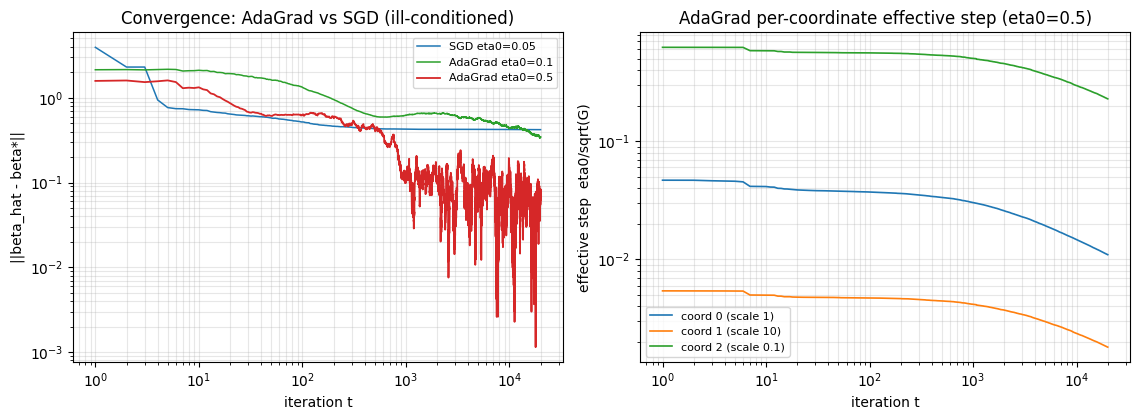

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
tt = np.arange(1, T + 1)

ax[0].loglog(tt, sgd_curves[0.05], color='#1f77b4', lw=1.1, label='SGD eta0=0.05')
ax[0].loglog(tt, ada_curves[0.1],  color='#2ca02c', lw=1.1, label='AdaGrad eta0=0.1')
ax[0].loglog(tt, ada_curves[0.5],  color='#d62728', lw=1.3, label='AdaGrad eta0=0.5')
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*||')
ax[0].set_title('Convergence: AdaGrad vs SGD (ill-conditioned)')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

lbl = ['coord 0 (scale 1)', 'coord 1 (scale 10)', 'coord 2 (scale 0.1)']
col = ['#1f77b4', '#ff7f0e', '#2ca02c']
for j in range(p):
    ax[1].loglog(tt, ada_eff[:, j], color=col[j], lw=1.2, label=lbl[j])
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('effective step  eta0/sqrt(G)')
ax[1].set_title('AdaGrad per-coordinate effective step (eta0=0.5)')
ax[1].legend(fontsize=8); ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

경험적 조건수 $\kappa(H)\approx3.7\times10^{4}$ 로 매우 크며, 열 스케일 $1:10:0.1$ 이 헤시안 고윳값을 크게 벌려 놓았다.
측정된 tail 오차: **SGD** 최선 $\eta_0{=}0.05$ → **0.421**, **AdaGrad** $\eta_0{=}0.2$ → 0.113,
$\eta_0{=}0.5$ → **0.059**.

1. **SGD 는 벽에 부딪힌다**(파랑). 안정성은 큰 곡률 좌표(scale 10)가 요구하는 작은 $\eta$ 로 묶이는데,
   그러면 작은 곡률 좌표(scale 0.1)는 거의 못 움직여 tail 이 0.42 아래로 내려가지 못한다 —
   §2.2 의 "단일 학습률 딜레마"가 그대로 나타난다.
2. **AdaGrad 는 스케일을 스스로 상쇄한다**(빨강). 좌표별 $1/\sqrt{G_{t,j}}$ 가 큰 그래디언트 좌표의
   스텝을 줄이고 작은 좌표의 스텝을 키워 **전처리**처럼 작동 → 같은 예산에서 tail 0.059 로 7배 정확.
3. **유효 스텝은 좌표마다 다르게 정착한다**(우측 패널). scale 10 좌표의 유효 스텝이 가장 작고,
   scale 0.1 좌표가 가장 커서, 세 좌표의 실질 갱신 크기가 **자동으로 균형**을 이룬다.
4. **하지만 세 곡선 모두 우하향**한다. $G_{t,j}$ 가 단조 증가하므로 유효 스텝은 $\propto t^{-1/2}$ 로
   0 을 향한다 — 정상 문제에선 수렴에 도움이 되지만, 목표가 움직이면(비정상) 이 감쇠가
   **추적 능력을 죽인다**.

> **결론**: AdaGrad = "좌표별 자동 전처리". 스케일 불일치를 스스로 상쇄해 ill-conditioned 스트림에서
> 단일-$\eta$ SGD 를 크게 앞선다. 단, $G$ 의 단조 누적이 유효 스텝을 0 으로 끌어내려 **비정상 추적에는 부적합**.

**다음 문제 연결**: Problem 2 에서 이 단조 누적을 **지수가중이동평균(EWMA)** 으로 바꾼
**RMSProp** 이 어떻게 유효 스텝을 살려 드리프트를 추적하는지, 그리고 감쇠계수 $\rho$ 가 만드는
편향-분산(기억길이) 트레이드오프를 본다.